<a href="https://colab.research.google.com/github/sk27110/DL2/blob/HW4/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.16.1
    Uninstalling huggingface_hub-1.16.1:
      Successfully uninstalled huggingface_hub-1.16.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, silhouette_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

В качестве модели возьмем DistilBert

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_SEQ_LENGTH = 128
BATCH_SIZE = 32

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

Возьмем подвыборку из imdb для быстрого обучения

In [ ]:
from datasets import load_dataset
import numpy as np


full_train = load_dataset("stanfordnlp/imdb", split="train")
full_test  = load_dataset("stanfordnlp/imdb", split="test")

shuffled_train = full_train.shuffle(seed=42)
shuffled_test  = full_test.shuffle(seed=42)

MAX_SAMPLES_TRAIN = 2000
MAX_SAMPLES_TEST  = 1000


samples_per_class_train = MAX_SAMPLES_TRAIN // 2
pos_train = np.where(np.array(full_train["label"]) == 1)[0][:samples_per_class_train].tolist()
neg_train = np.where(np.array(full_train["label"]) == 0)[0][:samples_per_class_train].tolist()
selected_train = pos_train + neg_train
np.random.shuffle(selected_train)

train_texts  = [full_train["text"][int(i)] for i in selected_train]
train_labels = [full_train["label"][int(i)] for i in selected_train]


samples_per_class_test = MAX_SAMPLES_TEST // 2
pos_test = np.where(np.array(full_test["label"]) == 1)[0][:samples_per_class_test].tolist()
neg_test = np.where(np.array(full_test["label"]) == 0)[0][:samples_per_class_test].tolist()
selected_test = pos_test + neg_test
np.random.shuffle(selected_test)

test_texts  = [full_test["text"][int(i)] for i in selected_test]
test_labels = [full_test["label"][int(i)] for i in selected_test]

print(f"Train: {len(train_texts)} ({samples_per_class_train} per class)")
print(f"Test : {len(test_texts)} ({samples_per_class_test} per class)")

Train: 2000 (1000 per class)
Test : 1000 (500 per class)


In [ ]:
def get_layer_hidden_states(texts, tokenizer, model, device, max_length, batch_size):
    all_hidden = []
    num_layers = model.config.num_hidden_layers + 1
    for i in range(num_layers):
        all_hidden.append([])
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, padding=True, truncation=True,
                           max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        hidden_states = outputs.hidden_states
        for layer_idx, h in enumerate(hidden_states):
            cls_vectors = h[:, 0, :].cpu().numpy()  # [CLS] токен
            all_hidden[layer_idx].append(cls_vectors)
    for layer_idx in range(num_layers):
        all_hidden[layer_idx] = np.concatenate(all_hidden[layer_idx], axis=0)
    return all_hidden

In [ ]:
train_hidden = get_layer_hidden_states(train_texts, tokenizer, model, device, MAX_SEQ_LENGTH, BATCH_SIZE)
test_hidden = get_layer_hidden_states(test_texts, tokenizer, model, device, MAX_SEQ_LENGTH, BATCH_SIZE)
num_layers = len(train_hidden)
layer_names = ["embed"] + [f"layer {i+1}" for i in range(num_layers-1)]

In [ ]:
def compute_kl_divergence(feat_normal, feat_anomaly, eps=1e-8):
    mu_n = np.mean(feat_normal, axis=0)
    sigma_n = np.var(feat_normal, axis=0) + eps
    mu_a = np.mean(feat_anomaly, axis=0)
    sigma_a = np.var(feat_anomaly, axis=0) + eps
    kl = 0.5 * (np.log(sigma_a / sigma_n) + (sigma_n + (mu_n - mu_a)**2) / sigma_a - 1)
    return np.mean(kl)

def compute_ldr(feat_normal, feat_anomaly, eps=1e-8):
    mu_n = np.mean(feat_normal, axis=0)
    sigma_n = np.var(feat_normal, axis=0)
    mu_a = np.mean(feat_anomaly, axis=0)
    sigma_a = np.var(feat_anomaly, axis=0)
    ldr = (mu_n - mu_a)**2 / (sigma_n + sigma_a + eps)
    return np.mean(ldr)

def compute_entropy(feat, bins=50):
    entropies = []
    for d in range(feat.shape[1]):
        hist, _ = np.histogram(feat[:, d], bins=bins)
        hist = hist / hist.sum() + 1e-10
        entropies.append(-np.sum(hist * np.log2(hist)))
    return np.mean(entropies)

In [ ]:
train_labels_np = np.array(train_labels)
normal_mask = train_labels_np == 0
anomaly_mask = train_labels_np == 1

In [ ]:
metrics = {"kl": [], "ldr": [], "entropy": [], "silhouette": [], "accuracy": [], "auc": []}

for layer_idx in range(num_layers):
    feat = train_hidden[layer_idx]

    unique_train_labels = np.unique(train_labels_np)
    if 0 in unique_train_labels and 1 in unique_train_labels:
        feat_normal = feat[train_labels_np == 0]
        feat_anomaly = feat[train_labels_np == 1]
        metrics["kl"].append(compute_kl_divergence(feat_normal, feat_anomaly))
        metrics["ldr"].append(compute_ldr(feat_normal, feat_anomaly))
    else:
        metrics["kl"].append(np.nan)
        metrics["ldr"].append(np.nan)

    metrics["entropy"].append(compute_entropy(feat))


    if len(unique_train_labels) > 1:
        scaler = StandardScaler()
        feat_scaled = scaler.fit_transform(feat)
        metrics["silhouette"].append(silhouette_score(feat_scaled, train_labels_np))
    else:
        metrics["silhouette"].append(np.nan)

    try:
        clf = LogisticRegression(max_iter=1000, solver="lbfgs")
        clf.fit(feat, train_labels_np)
        preds = clf.predict(test_hidden[layer_idx])
        probs = clf.predict_proba(test_hidden[layer_idx])[:, 1]
        metrics["accuracy"].append(accuracy_score(test_labels, preds))
        metrics["auc"].append(roc_auc_score(test_labels, probs))
    except:
        metrics["accuracy"].append(np.nan)
        metrics["auc"].append(np.nan)

In [ ]:
def zscore_normalize(arr):
    arr = np.array(arr)
    return (arr - np.mean(arr)) / (np.std(arr) + 1e-8)

saliency = (zscore_normalize(metrics["kl"]) +
            zscore_normalize(metrics["ldr"]) +
            zscore_normalize(metrics["entropy"]))
best_layer_idx = np.argmax(saliency)

In [ ]:
print(f"Лучший слой по DLSP: {layer_names[best_layer_idx]} (индекс {best_layer_idx})")

Лучший слой по DLSP: layer 6 (индекс 6)


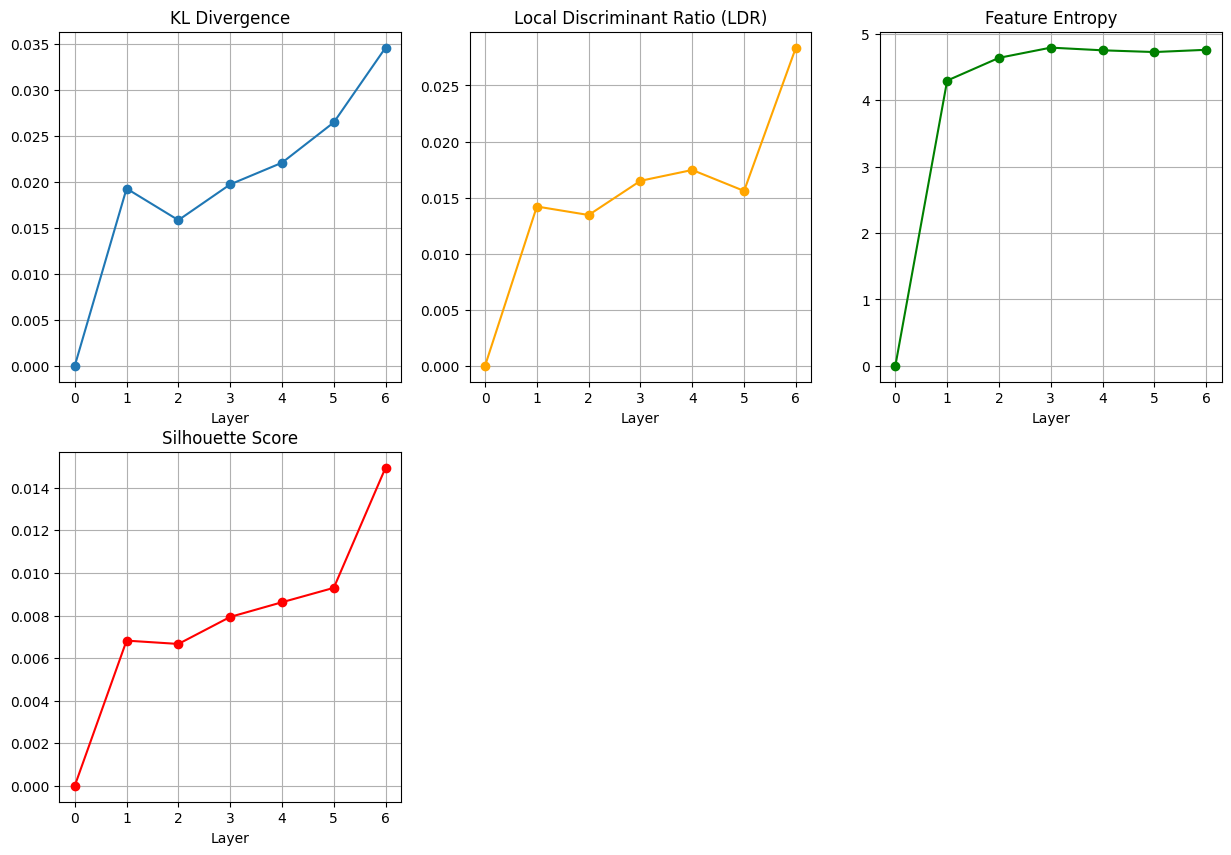

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(range(num_layers), metrics["kl"], marker='o')
plt.title("KL Divergence")
plt.xlabel("Layer")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(range(num_layers), metrics["ldr"], marker='o', color='orange')
plt.title("Local Discriminant Ratio (LDR)")
plt.xlabel("Layer")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(range(num_layers), metrics["entropy"], marker='o', color='green')
plt.title("Feature Entropy")
plt.xlabel("Layer")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(range(num_layers), metrics["silhouette"], marker='o', color='red')
plt.title("Silhouette Score")
plt.xlabel("Layer")
plt.grid(True)

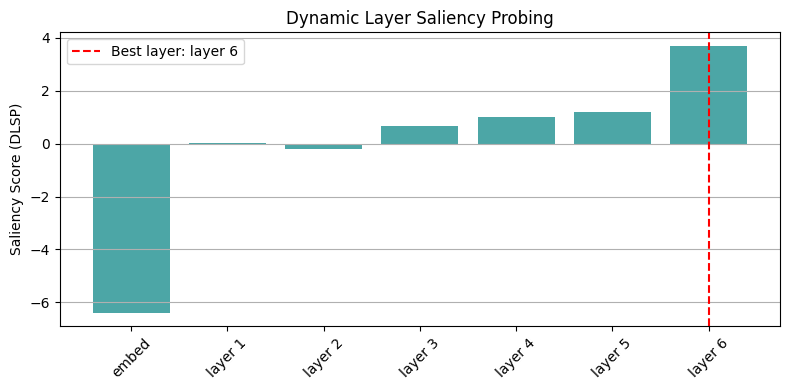

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(num_layers), saliency, color='teal', alpha=0.7)
plt.axvline(best_layer_idx, color='red', linestyle='--', label=f'Best layer: {layer_names[best_layer_idx]}')
plt.xticks(range(num_layers), layer_names, rotation=45)
plt.ylabel("Saliency Score (DLSP)")
plt.title("Dynamic Layer Saliency Probing")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df_results = pd.DataFrame({
    "Layer": layer_names,
    "KL": metrics["kl"],
    "LDR": metrics["ldr"],
    "Entropy": metrics["entropy"],
    "Silhouette": metrics["silhouette"],
    "Accuracy": metrics["accuracy"],
    "AUC": metrics["auc"],
    "Saliency": saliency
})
print("\nРезультаты по слоям:")
print(df_results.round(4))


Результаты по слоям:
     Layer      KL     LDR  Entropy  Silhouette  Accuracy     AUC  Saliency
0    embed  0.0000  0.0000   0.0000      0.0000     0.500  0.5000   -6.4010
1  layer 1  0.0193  0.0142   4.2945      0.0068     0.711  0.7761    0.0252
2  layer 2  0.0158  0.0134   4.6369      0.0067     0.750  0.8340   -0.2134
3  layer 3  0.0197  0.0165   4.7908      0.0079     0.732  0.7860    0.6716
4  layer 4  0.0221  0.0175   4.7504      0.0086     0.728  0.8087    1.0121
5  layer 5  0.0264  0.0156   4.7243      0.0093     0.768  0.8432    1.1995
6  layer 6  0.0346  0.0284   4.7581      0.0149     0.813  0.8931    3.7059


In [ ]:
auc_values = np.array(metrics["auc"])
top3_indices = np.argsort(auc_values)[-3:]
top3_names = [layer_names[i] for i in top3_indices]
print(f"Топ-3 слоя по AUC: {top3_names} (индексы: {top3_indices})")

train_feat_top3 = np.concatenate([train_hidden[i] for i in top3_indices], axis=1)
test_feat_top3  = np.concatenate([test_hidden[i] for i in top3_indices], axis=1)

clf_top3 = LogisticRegression(max_iter=1000, solver="lbfgs")
clf_top3.fit(train_feat_top3, train_labels_np)

preds_top3 = clf_top3.predict(test_feat_top3)
probs_top3 = clf_top3.predict_proba(test_feat_top3)[:, 1]
acc_top3 = accuracy_score(test_labels, preds_top3)
auc_top3 = roc_auc_score(test_labels, probs_top3)
print(f"Комбинированный классификатор (топ-3 слоя) -> Accuracy: {acc_top3:.4f}, AUC: {auc_top3:.4f}")

combo_acc = acc_top3
combo_auc = auc_top3

Топ-3 слоя по AUC: ['layer 2', 'layer 5', 'layer 6'] (индексы: [2 5 6])
Комбинированный классификатор (топ-3 слоя) -> Accuracy: 0.8010, AUC: 0.8798


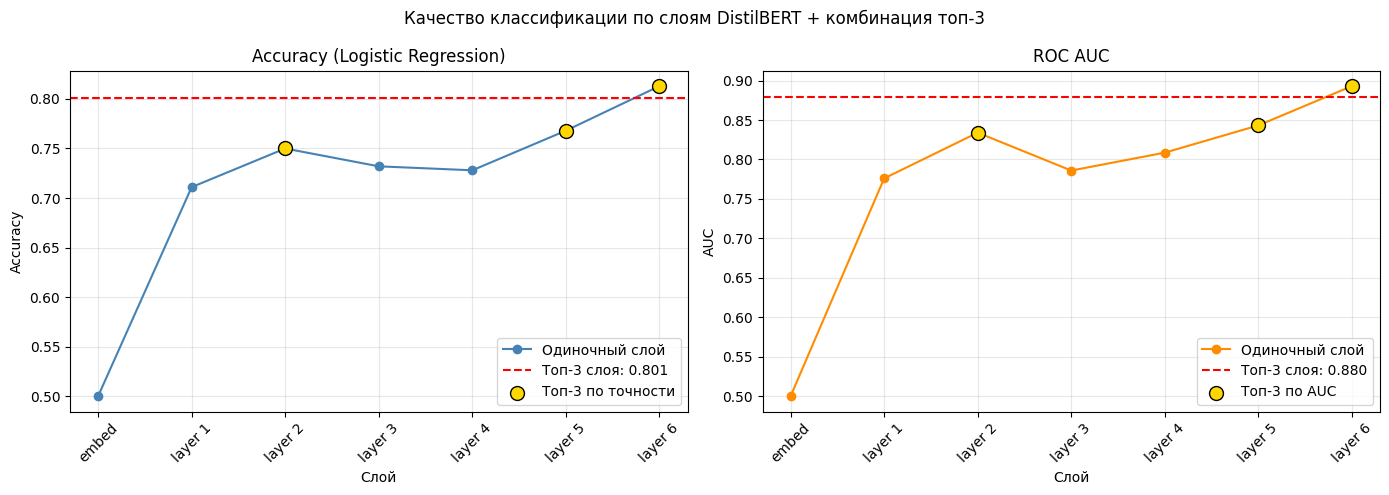

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(range(num_layers), metrics["accuracy"], marker='o', label='Одиночный слой', color='steelblue')
ax1.axhline(y=combo_acc, color='red', linestyle='--', label=f'Топ-3 слоя: {combo_acc:.3f}')

best_acc_indices = np.argsort(metrics["accuracy"])[-3:]
ax1.scatter(best_acc_indices, np.array(metrics["accuracy"])[best_acc_indices],
            color='gold', s=100, edgecolors='black', zorder=5, label='Топ-3 по точности')
ax1.set_xticks(range(num_layers))
ax1.set_xticklabels(layer_names, rotation=45)
ax1.set_title("Accuracy (Logistic Regression)")
ax1.set_xlabel("Слой")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.3)
ax1.legend()


ax2.plot(range(num_layers), metrics["auc"], marker='o', label='Одиночный слой', color='darkorange')
ax2.axhline(y=combo_auc, color='red', linestyle='--', label=f'Топ-3 слоя: {combo_auc:.3f}')

best_auc_indices = np.argsort(metrics["auc"])[-3:]
ax2.scatter(best_auc_indices, np.array(metrics["auc"])[best_auc_indices],
            color='gold', s=100, edgecolors='black', zorder=5, label='Топ-3 по AUC')
ax2.set_xticks(range(num_layers))
ax2.set_xticklabels(layer_names, rotation=45)
ax2.set_title("ROC AUC")
ax2.set_xlabel("Слой")
ax2.set_ylabel("AUC")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle("Качество классификации по слоям DistilBERT + комбинация топ-3")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
df_results = pd.DataFrame({
    "Слой": layer_names,
    "Accuracy": metrics["accuracy"],
    "AUC": metrics["auc"],
    "Silhouette": metrics["silhouette"],
    "KL": metrics["kl"],
    "LDR": metrics["ldr"],
    "Entropy": metrics["entropy"]
})
df_results = df_results.round(4)
print("\nРезультаты по отдельным слоям:")
print(df_results)

print("\nТоп-3 слоя (конкатенация):")
print(f"Слои: {top3_names}")
print(f"Accuracy: {combo_acc:.4f}, AUC: {combo_auc:.4f}")


Результаты по отдельным слоям:
      Слой  Accuracy     AUC  Silhouette      KL     LDR  Entropy
0    embed     0.500  0.5000      0.0000  0.0000  0.0000   0.0000
1  layer 1     0.711  0.7761      0.0068  0.0193  0.0142   4.2945
2  layer 2     0.750  0.8340      0.0067  0.0158  0.0134   4.6369
3  layer 3     0.732  0.7860      0.0079  0.0197  0.0165   4.7908
4  layer 4     0.728  0.8087      0.0086  0.0221  0.0175   4.7504
5  layer 5     0.768  0.8432      0.0093  0.0264  0.0156   4.7243
6  layer 6     0.813  0.8931      0.0149  0.0346  0.0284   4.7581

Топ-3 слоя (конкатенация):
Слои: ['layer 2', 'layer 5', 'layer 6']
Accuracy: 0.8010, AUC: 0.8798


В результате лучшим оказался последний 6 слой. На 2 и 3 местах 5 и 2 слои. Большая информативность последнего слоя объясняется тем, что distilbert - маленькая модель, поэтому последние слои еще не предназначены для конкретной задачи, при этом собирают максимум нужных для классификации признаков.